In this notebook, we transform the raw data into machine learning–ready features on a per-timestep and per-engine basis.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

# Load Data

In [46]:
# We load the data from the previous notebook
df = pd.read_parquet("../data/processed/fd001_clean.parquet")

In [7]:
df.head()

,engine_number,time_cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [9]:
df.tail()

,engine_number,time_cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640
20630,100,200,-0.0032,-0.0005,100.0,518.67,643.85,1600.38,1432.14,14.62,...,519.30,2388.26,8137.33,8.5036,0.03,396,2388,100.0,38.37,23.0522


As mentioned in `01_data_exploration.ipynb`, the data is already ordered by engine number and time cycle. Therefore, there is no need to reorder or restructure the dataset.

# Creating the Target Variable (RUL)

Since our target variable is not yet included in the dataset, we construct it manually. The process is straightforward:

First, we determine the maximum cycle for each engine.  
Then, we subtract the current cycle from this maximum cycle to obtain the Remaining Useful Life (RUL).

In [47]:
max_cycles = df.groupby('engine_number')['time_cycle'].transform('max')
df['RUL'] = max_cycles - df['time_cycle']

# Removing Constant Sensors

We remove the sensors that exhibit no variation, as they provide no meaningful information for downstream models. These constant features were previously identified in `01_data_exploration.ipynb`.

In [48]:
# constant sensors from notebook 1
constant_sensors = ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
df = df.drop(constant_sensors, axis=1)
df.columns

Index(['engine_number', 'time_cycle', 'setting_1', 'setting_2', 'setting_3',
       'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8',
       'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14',
       'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'RUL'],
      dtype='str')

# Creating the First Simple Engineered Features

As established in `01_data_exploration.ipynb`, feature engineering is a crucial step in this project to ensure that the models can capture meaningful degradation patterns despite the noisy and highly fluctuating sensor signals.

We begin by creating rolling mean features. For this purpose, we first need to determine an appropriate window size.

In [33]:
# Since our window size must be smaller than the shortest engine lifetime in the training set in order to avoid
# introducing NaN values across entire sequences, we first revisit the engine lifespans previously computed in
# Notebook 1.

# How long does each engine run?
engine_lifespans = df.groupby('engine_number')['time_cycle'].max()

print("\n--- Lifespan of the engines (cycles) ---\n")

engine_lifespans.describe()


--- Lifespan of the engines (cycles) ---



count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: time_cycle, dtype: float64

We recall that the window size must be smaller than 128, the shortest engine lifespan, which should not pose any issue.

Next, we compute the point at which the correlation between time cycles begins to decrease, as this indicates the optimal window boundary.

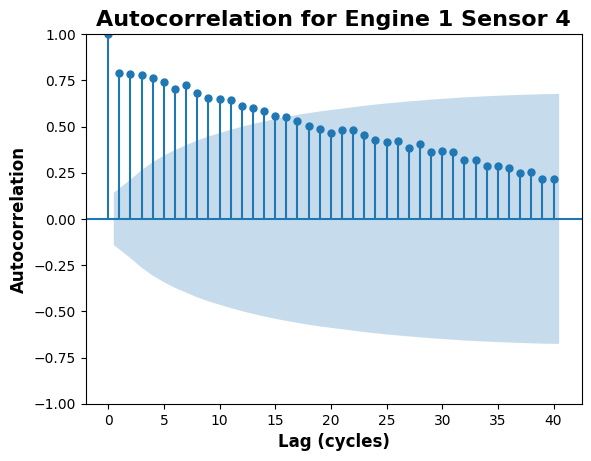

In [8]:
single_engine_df = df[df['engine_number'] == 1]


# Plot autocorrelation for sensor 4 which had the strongest increase in percentage change
plot_acf(single_engine_df['sensor_4'], lags=40)
plt.title('Autocorrelation for Engine 1 Sensor 4', fontsize=16, fontweight='bold')
plt.xlabel('Lag (cycles)', fontsize=12, fontweight='bold')
plt.ylabel('Autocorrelation', fontsize=12, fontweight='bold')
plt.show()

We observe that the optimal window boundary lies between 15 and 20 cycles, as the autocorrelation plot intersects the confidence interval around the zero correlation level in this region.

Next, we determine this optimal boundary more precisely in a numerical way, instead of relying on rough estimates.

In [10]:
acf_values, conf_int = acf(single_engine_df['sensor_4'], nlags=40, alpha=0.05)

ideal_window = None
for lag in range(1, len(acf_values)):
    upper_bound = conf_int[lag][1] - acf_values[lag]
    if abs(acf_values[lag]) <= upper_bound:
        ideal_window = lag
        break

if ideal_window:
    print(f"w = {ideal_window}")
else:
    print("Not crossed. Use standard w = 15.")

w = 17


## Window Sizes for Rolling Feature Engineering (NASA FD001)

The selection of rolling window sizes is directly grounded in the single-engine autocorrelation (ACF) analysis. The observed correlation structure indicates strong temporal dependence at small lags, followed by a transition into the statistical noise region beyond lag 17. Consequently, 17 represents a practical upper bound for extracting meaningful historical information.

**1. Rolling Mean Window (w = 17)**  
- The rolling mean is computed exclusively with a window size of 17 cycles.  
- This choice is directly derived from the ACF analysis, where statistically meaningful temporal correlation disappears beyond lag 17.  
- A larger rolling mean window strongly smooths the highly noisy sensor trajectories and highlights the underlying long-term degradation trend rather than short-term fluctuations.  
- Since the rolling mean is intended to model the global degradation progression, prioritizing stability and noise reduction is desirable.

**2. Rolling Standard Deviation Window (w = 10)**  
- The rolling standard deviation is computed using a smaller window size of 10 cycles.  
- Standard deviation is intended to capture local fluctuations and short-term instability in sensor behavior.  
- A larger window such as 17 would excessively smooth these local volatility patterns and reduce sensitivity to sudden increases in operational instability close to failure.  
- The 10-cycle window therefore provides a better balance between noise suppression and responsiveness to short-term degradation dynamics.

Overall, this configuration separates the modeling objectives clearly: the rolling mean captures long-term degradation structure, while the rolling standard deviation focuses on localized instability patterns.

In [49]:
sensor_cols = [
    'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7',
    'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13',
    'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21'
]

# Window configurations
roll_mean_window = 17
roll_std_window = 10

In [50]:
# -------------------------------------------------------------------
# Rolling Mean Features (w = 17)
# Captures long-term degradation trends with strong noise smoothing
# -------------------------------------------------------------------
for sensor in sensor_cols:

    df[f'{sensor}_roll_mean_{roll_mean_window}'] = (
        df.groupby('engine_number')[sensor]
        .rolling(window=roll_mean_window, min_periods=roll_mean_window)
        .mean()
        .reset_index(level=0, drop=True)
    )




In [52]:
# -------------------------------------------------------------------
# Rolling Standard Deviation Features (w = 10)
# Captures short-term instability and local sensor fluctuations
# -------------------------------------------------------------------
for sensor in sensor_cols:

    df[f'{sensor}_roll_std_{roll_std_window}'] = (
        df.groupby('engine_number')[sensor]
        .rolling(window=roll_std_window, min_periods=roll_std_window)
        .std()
        .reset_index(level=0, drop=True)
    )


## Rolling Slope Features

In addition to rolling statistics such as mean and standard deviation, we now introduce rolling slope features to capture the local trend direction of each sensor signal.

The rolling slope is computed by fitting a simple linear regression within a sliding window over time. It represents the rate of change of the sensor values and therefore provides a direct measure of whether a signal is increasing, decreasing, or remaining stable within a given time horizon.

Positive slope values indicate an increasing trend in the sensor signal, which may be associated with progressive wear or intensifying operating conditions. Negative slope values indicate a decreasing trend, which may reflect loss of performance or declining system pressure. Values close to zero suggest a stable or stationary behavior within the respective window.

This feature is particularly useful for detecting degradation dynamics, as it allows the model to explicitly learn trend direction and acceleration patterns rather than relying solely on smoothed level-based statistics.

To capture both long-term degradation behavior and short-term pre-failure acceleration, we construct rolling slope features using two complementary window sizes for selected sensors (e.g., `sensor_4`).

Each window focuses on a distinct temporal aspect of engine degradation:

* **`sensor4_slope_17` (Long-Term Trend Indicator):**  
  Derived from the ACF-based upper correlation boundary, this larger window suppresses high-frequency sensor noise and captures the stable, long-term degradation trajectory of the engine. It emphasizes persistent directional trends rather than short-lived fluctuations.

* **`sensor4_slope_5` (Acute Acceleration Indicator):**  
  A highly localized window designed to detect sudden changes in sensor dynamics close to failure. Although more sensitive to noise, it reacts rapidly to sharp degradation acceleration during the final operational cycles before breakdown.

In [54]:
def get_slope(y):
    x = np.arange(len(y))
    return np.sum((x - x.mean()) * (y - y.mean())) / np.sum((x - x.mean()) ** 2)

In [55]:
window_sizes_slope = [5, 17]

In [56]:
for s in sensor_cols:
    for w in window_sizes_slope:
        df[f"{s}_slope_{w}"] = (
            df.groupby("engine_number")[s]
            .rolling(w, min_periods=w)
            .apply(get_slope, raw=True)
            .reset_index(level=0, drop=True)
        )

## Handling of NaN Values Introduced by Rolling Features

Rolling statistics and slope features introduce NaN values at the beginning of each engine trajectory due to insufficient historical context within the sliding windows.

Since these early cycles correspond to the healthy operating phase of the engine, where no meaningful degradation information is present, we remove these initial observations from the dataset.

This approach ensures a clean feature space for model training without distorting the underlying degradation patterns.

For both rolling statistics and slope features, the largest window size is 17. Therefore, it is sufficient to remove rows containing NaN values in the corresponding 17-cycle feature columns.

Since all smaller rolling windows (`w = 5` and `w = 10`) require fewer historical observations, their valid regions are already fully contained within the valid region of the 17-cycle features. Consequently, removing NaN rows for the largest window automatically removes all NaN values generated by the smaller windows as well..

In [60]:
# Generate the list of columns that use the 17-window
cols_to_check = [f"{s}_slope_17" for s in sensor_cols]

# Drop rows with NaN values in these specific columns
df = df.dropna(subset=cols_to_check)

# Optional check: Print the number of remaining rows
print(f"Remaining rows in the dataset: {len(df)}")

Remaining rows in the dataset: 19031


In [64]:
df.isna().sum()

engine_number         0
time_cycle            0
setting_1             0
setting_2             0
setting_3             0
                     ..
sensor_17_slope_17    0
sensor_20_slope_5     0
sensor_20_slope_17    0
sensor_21_slope_5     0
sensor_21_slope_17    0
Length: 81, dtype: int64

In [65]:
len(df.columns)

81

In [66]:
df.columns

Index(['engine_number', 'time_cycle', 'setting_1', 'setting_2', 'setting_3',
       'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8',
       'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14',
       'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'RUL',
       'sensor_2_roll_mean_17', 'sensor_3_roll_mean_17',
       'sensor_4_roll_mean_17', 'sensor_6_roll_mean_17',
       'sensor_7_roll_mean_17', 'sensor_8_roll_mean_17',
       'sensor_9_roll_mean_17', 'sensor_11_roll_mean_17',
       'sensor_12_roll_mean_17', 'sensor_13_roll_mean_17',
       'sensor_14_roll_mean_17', 'sensor_15_roll_mean_17',
       'sensor_17_roll_mean_17', 'sensor_20_roll_mean_17',
       'sensor_21_roll_mean_17', 'sensor_2_roll_std_10',
       'sensor_3_roll_std_10', 'sensor_4_roll_std_10', 'sensor_6_roll_std_10',
       'sensor_7_roll_std_10', 'sensor_8_roll_std_10', 'sensor_9_roll_std_10',
       'sensor_11_roll_std_10', 'sensor_12_roll_std_10',
       'sensor_13_roll_std_10